# Sampling and generative modelling illustration

This notebook creates a two-panel figure for the MMD presentation: sampling from an unnormalised density and generative modelling from samples.

/tmp/ipykernel_498917/1926728045.py:135: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc="upper right", frameon=False, handletextpad=0.25, borderpad=0.1, fontsize=9)


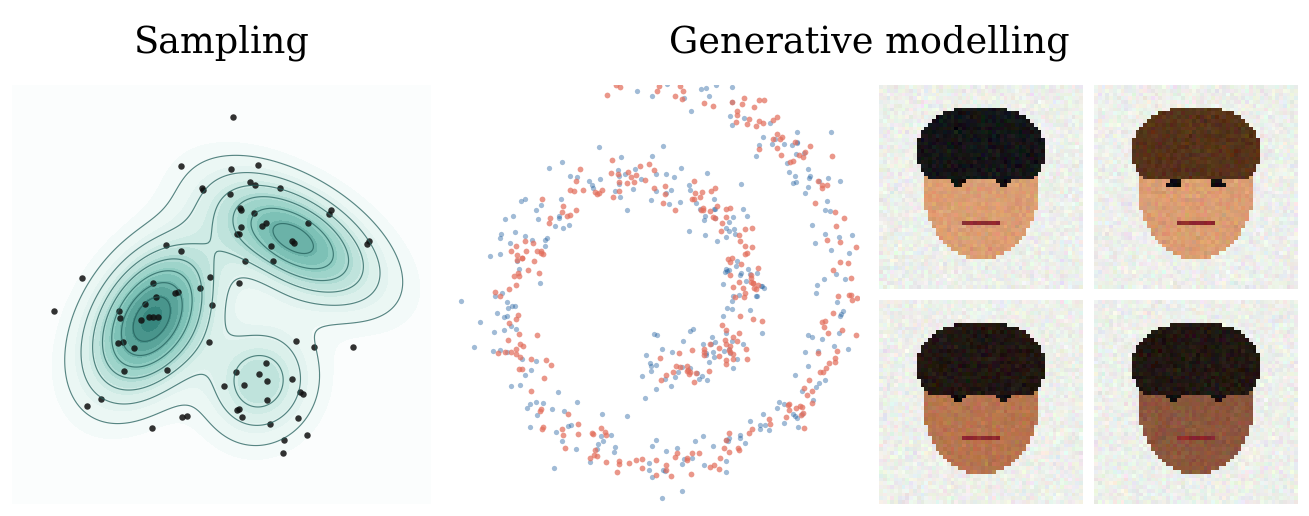

Saved figures/sampling_generative_illustration.pdf


In [1]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "axes.titlesize": 22,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
})

rng = np.random.default_rng(4)

def gaussian_bump(x, y, mean, cov):
    dx = np.stack([x - mean[0], y - mean[1]], axis=-1)
    inv_cov = np.linalg.inv(cov)
    exponent = np.einsum("...i,ij,...j->...", dx, inv_cov, dx)
    return np.exp(-0.5 * exponent)

def resize_nearest(image, size=54):
    y_idx = np.linspace(0, image.shape[0] - 1, size).astype(int)
    x_idx = np.linspace(0, image.shape[1] - 1, size).astype(int)
    return image[y_idx][:, x_idx]

def center_crop_square(image):
    height, width = image.shape[:2]
    side = min(height, width)
    top = (height - side) // 2
    left = (width - side) // 2
    return image[top:top + side, left:left + side]

def synthetic_face_thumbnail(rng, size=54):
    yy, xx = np.mgrid[-1:1:complex(size), -1:1:complex(size)]
    image = np.ones((size, size, 3)) * np.array([0.93, 0.94, 0.92])
    skin = np.array(rng.choice([
        [0.86, 0.62, 0.45], [0.72, 0.46, 0.31], [0.96, 0.76, 0.57], [0.55, 0.34, 0.24]
    ]))
    hair = np.array(rng.choice([
        [0.13, 0.09, 0.07], [0.34, 0.20, 0.10], [0.68, 0.48, 0.24], [0.08, 0.08, 0.09]
    ]))
    face = (xx / 0.58) ** 2 + ((yy + 0.03) / 0.76) ** 2 < 1.0
    hair_mask = (xx / 0.66) ** 2 + ((yy + 0.36) / 0.45) ** 2 < 1.0
    image[face] = skin
    image[hair_mask & (yy < -0.08)] = hair
    eye_y = -0.06 + rng.normal(0, 0.025)
    for eye_x in (-0.22, 0.22):
        eye = ((xx - eye_x) / 0.07) ** 2 + ((yy - eye_y) / 0.035) ** 2 < 1.0
        image[eye] = np.array([0.06, 0.05, 0.05])
    mouth = ((yy - 0.35) / 0.025) ** 2 + (xx / 0.22) ** 2 < 1.0
    image[mouth] = np.array([0.55, 0.16, 0.18])
    return np.clip(image + rng.normal(0, 0.025, image.shape), 0, 1)

def make_image_grid(images, rows=2, cols=4, pad=3):
    tile_h, tile_w = images[0].shape[:2]
    grid = np.ones((rows * tile_h + (rows - 1) * pad, cols * tile_w + (cols - 1) * pad, 3))
    for idx, image in enumerate(images[:rows * cols]):
        row, col = divmod(idx, cols)
        y0 = row * (tile_h + pad)
        x0 = col * (tile_w + pad)
        grid[y0:y0 + tile_h, x0:x0 + tile_w] = image[:, :, :3]
    return grid

def load_celeba_grid(rng, rows=2, cols=2, size=54):
    search_dirs = ["celeba_samples", "data/celeba_samples", "../data/celeba_samples"]
    paths = []
    for directory in search_dirs:
        for pattern in ("*.jpg", "*.jpeg", "*.png"):
            paths.extend(sorted(glob.glob(os.path.join(directory, pattern))))
    if paths:
        images = []
        for path in paths[:rows * cols]:
            image = plt.imread(path)
            if image.dtype.kind in "ui":
                image = image / np.iinfo(image.dtype).max
            image = center_crop_square(image[:, :, :3])
            images.append(resize_nearest(image, size=size))
        return make_image_grid(images, rows=rows, cols=cols), True
    images = [synthetic_face_thumbnail(rng, size=size) for _ in range(rows * cols)]
    return make_image_grid(images, rows=rows, cols=cols), False

grid = np.linspace(-3.0, 3.0, 240)
X, Y = np.meshgrid(grid, grid)
unnormalised_density = (
    1.15 * gaussian_bump(X, Y, mean=(-1.0, -0.35), cov=np.array([[0.38, 0.18], [0.18, 0.55]]))
    + 0.95 * gaussian_bump(X, Y, mean=(1.05, 0.8), cov=np.array([[0.65, -0.26], [-0.26, 0.38]]))
    + 0.55 * gaussian_bump(X, Y, mean=(0.55, -1.25), cov=np.array([[0.28, 0.02], [0.02, 0.32]]))
)

weights = np.array([1.15, 0.95, 0.55])
means = np.array([[-1.0, -0.35], [1.05, 0.8], [0.55, -1.25]])
covs = np.array([
    [[0.38, 0.18], [0.18, 0.55]],
    [[0.65, -0.26], [-0.26, 0.38]],
    [[0.28, 0.02], [0.02, 0.32]],
])
component_ids = rng.choice(len(weights), size=80, p=weights / weights.sum())
target_samples = np.vstack([
    rng.multivariate_normal(means[k], covs[k]) for k in component_ids
])

n = 320
t = 1.5 * np.pi * (1 + 2 * rng.random(n))
noise = 0.18 * rng.normal(size=(n, 2))
real_samples = np.column_stack((t * np.cos(t), t * np.sin(t))) / 5.4 + noise
generator_samples = np.column_stack(((t + 0.25) * np.cos(t + 0.25), (t + 0.25) * np.sin(t + 0.25))) / 5.4
generator_samples += 0.13 * rng.normal(size=(n, 2)) + np.array([0.06, -0.04])

celeba_grid, has_celeba_files = load_celeba_grid(rng)

fig = plt.figure(figsize=(10.8, 4.2), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[0.15, 1.0], width_ratios=[1.0, 1.0, 1.0])
sampling_title_ax = fig.add_subplot(gs[0, 0])
sampling_title_ax.axis("off")
sampling_title_ax.text(0.5, 0.22, "Sampling", ha="center", va="bottom", fontsize=22)
group_title_ax = fig.add_subplot(gs[0, 1:])
group_title_ax.axis("off")
group_title_ax.text(0.5, 0.22, "Generative modelling", ha="center", va="bottom", fontsize=22)
axs = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]
density_cmap = mcolors.LinearSegmentedColormap.from_list(
    "density_teal", ["#ffffff", "#d7eee9", "#86c9bd", "#2f7f78"]
)

axs[0].contourf(X, Y, unnormalised_density, levels=18, cmap=density_cmap)
axs[0].contour(X, Y, unnormalised_density, levels=8, colors="#235f5b", linewidths=0.7, alpha=0.75)
axs[0].scatter(target_samples[:, 0], target_samples[:, 1], s=15, c="#111111", alpha=0.86, linewidths=0)
axs[0].set_xlim(-3, 3)
axs[0].set_ylim(-3, 3)

axs[1].scatter(real_samples[:, 0], real_samples[:, 1], s=10, c="#1f5f9f", alpha=0.42, linewidths=0)
axs[1].scatter(generator_samples[:, 0], generator_samples[:, 1], s=12, c="#e36f5d", alpha=0.72, linewidths=0)
axs[1].legend(loc="upper right", frameon=False, handletextpad=0.25, borderpad=0.1, fontsize=9)
axs[1].set_xlim(-2.6, 2.6)
axs[1].set_ylim(-2.6, 2.6)

axs[2].imshow(celeba_grid)

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

save_path = "figures/sampling_generative_illustration.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved {save_path}")